# Wine Quality — K-Fold Cross-Validation

In [1]:
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.model_selection import KFold
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [2]:
class MyRandomClassifier(ClassifierMixin):

    def __init__(self, random_state: int = 42):
        self.random_state = random_state

    def fit(self, X, y):
        self.labels = np.unique(y)

    def predict(self, X):
        self.y = np.random.choice(self.labels, size=len(X))
        return self.y

In [3]:
red   = pd.read_csv('winequality/winequality-red.csv', sep=';')
white = pd.read_csv('winequality/winequality-white.csv', sep=';')

red['tipo']   = 'tinto'
white['tipo'] = 'branco'

wine = pd.concat([red, white], ignore_index=True)
wine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,tipo
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,tinto
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,tinto
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,tinto
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,tinto
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,tinto


In [4]:
wine["good_quality"] = (wine["quality"] >= 7).astype(int)

X = wine.drop(columns=["quality", "good_quality"])
X = pd.get_dummies(X, columns=["tipo"], drop_first=True)
y = wine["good_quality"]

print(X.shape, y.shape)

(6497, 12) (6497,)


In [5]:
dummy_classifier = DummyClassifier(strategy="most_frequent", random_state=42)
rand_classifier  = MyRandomClassifier(random_state=42)
tree_classifier  = DecisionTreeClassifier(random_state=42)

kf = KFold(n_splits=5)
kf.get_n_splits()
print(kf)

predicts = {
    "dummy":  [],
    "random": [],
    "tree":   []
}

for train_index, test_index in kf.split(X):
    print("TRAIN:", train_index, "TEST:", test_index)

    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    print(X_train.shape, X_test.shape)

    tree_classifier.fit(X_train, y_train)
    dummy_classifier.fit(X_train, y_train)
    rand_classifier.fit(X_train, y_train)

    y_dummy = dummy_classifier.predict(X_test)
    y_rand  = rand_classifier.predict(X_test)
    y_tree  = tree_classifier.predict(X_test)

    predicts["dummy"].append(accuracy_score(y_test, y_dummy))
    predicts["random"].append(accuracy_score(y_test, y_rand))
    predicts["tree"].append(accuracy_score(y_test, y_tree))

KFold(n_splits=5, random_state=None, shuffle=False)
TRAIN: [1300 1301 1302 ... 6494 6495 6496] TEST: [   0    1    2 ... 1297 1298 1299]
(5197, 12) (1300, 12)
TRAIN: [   0    1    2 ... 6494 6495 6496] TEST: [1300 1301 1302 ... 2597 2598 2599]
(5197, 12) (1300, 12)
TRAIN: [   0    1    2 ... 6494 6495 6496] TEST: [2600 2601 2602 ... 3896 3897 3898]
(5198, 12) (1299, 12)
TRAIN: [   0    1    2 ... 6494 6495 6496] TEST: [3899 3900 3901 ... 5195 5196 5197]
(5198, 12) (1299, 12)
TRAIN: [   0    1    2 ... 5195 5196 5197] TEST: [5198 5199 5200 ... 6494 6495 6496]
(5198, 12) (1299, 12)


In [6]:
print("Resultados K-Fold (5 folds):")
for model, scores in predicts.items():
    print(f"  {model}: {np.mean(scores):.4f} ± {np.std(scores):.4f}")

Resultados K-Fold (5 folds):
  dummy: 0.8034 ± 0.0351
  random: 0.5022 ± 0.0108
  tree: 0.7586 ± 0.0436


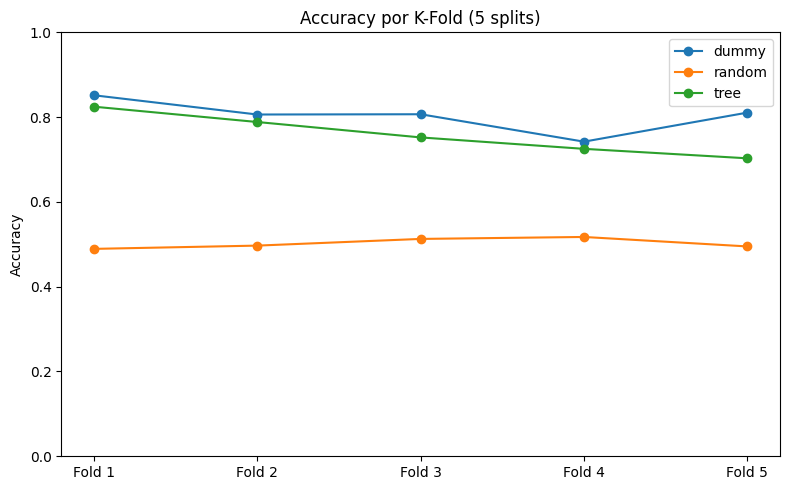

In [8]:
import matplotlib.pyplot as plt

folds = range(1, 6)

plt.figure(figsize=(8, 5))
for model, scores in predicts.items():
    plt.plot(folds, scores, marker='o', label=model)

plt.xticks(folds, [f"Fold {i}" for i in folds])
plt.ylabel("Accuracy")
plt.title("Accuracy por K-Fold (5 splits)")
plt.legend()
plt.ylim(0, 1)
plt.tight_layout()
plt.show()